**Arquitectura de Software a Gran Escala, 2026i**</br>
Jeisson Andrés Vergara Vargas

# Verificación Arquitectónica — Subsistema de Notificación

## Descripción

En este laboratorio se explorará el **Subsistema de Notificación** (modelado en `subsystem_model.sos`) de la arquitectura COSO a través de una simulación utilizando el lenguaje de programación Python. Utilizando un modelo arquitectónico base, se han agregado funciones para soportar el patrón arquitectónico de **balanceo de carga**.

El subsistema gestiona el flujo de alertas desde sistemas externos (`data_adquisition_system`, `c4_system`) hacia diversos canales de notificación (SMS, radio CAP, push).

## Objetivo General

Desarrollar una comprensión profunda de la arquitectura de software a gran escala mediante el modelado, simulación y análisis del subsistema de notificación. Además, evidenciar cómo las tácticas arquitectónicas son útiles para soportar atributos de calidad como el rendimiento, la disponibilidad, etc.

## Objetivos Específicos

1. **Modelado**: Construir una representación abstracta de la arquitectura del subsistema de notificación.
2. **Instanciación**: Crear y configurar los componentes que conforman la arquitectura del sistema.
3. **Balanceo de carga**: Utilizar técnicas de balanceo de carga para soportar el tráfico en momentos en que los componentes no tienen la capacidad completa.
4. **Resultados**: Analizar los datos obtenidos para identificar comportamientos exitosos y fallidos, así como los componentes críticos que afectan al sistema. Analizar los resultados en cada una de las técnicas de balanceo de carga aplicadas.

# Pasos de Ejecución

1. Modelado
2. Simulación con gráfico / simulación sin gráfico
3. Ejecutar alguna de las secciones de arquitectura
   - Arquitectura original
   - Balanceador de carga básico
   - Múltiple balanceador de carga
   - Round Robin (RR)
   - Round Robin ponderado
4. Ejecutar la simulación

# Modelado

In [3]:
pip install networkx matplotlib

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 89.0 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import threading
import time
import random
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# ================================
# 1. Modeling
# ================================

class Component:
    """
    Base class for all architecture components.
    """
    def __init__(self, name, component_type, capacity=100):
        self.name = name
        self.component_type = component_type
        self.capacity = capacity
        self.lock = threading.Lock()
        self.current_load = 0

    def process_transaction(self, transaction):
        """
        Processes a transaction. Returns True if the transaction is processed successfully,
        or False if the component's capacity is exceeded.
        """
        with self.lock:
            if self.current_load >= self.capacity:
                return False  # Over capacity failure
            self.current_load += 1
        # Simulate processing time
        processing_time = random.uniform(0.01, 0.05)
        time.sleep(processing_time)
        with self.lock:
            self.current_load -= 1
        return True

class PresentationTier(Component):
    """
    Class for API Gateway components (Presentation Tier)
    """
    def __init__(self, name, capacity=100):
        super().__init__(name, "Presentation Tier", capacity)

class LogicTier(Component):
    """
    Class for microservice and logic components (Logic Tier)
    """
    def __init__(self, name, capacity=100):
        super().__init__(name, "Logic Tier", capacity)

class ExternalServiceTier(Component):
    """
    Class for external service components (External Service Tier)
    """
    def __init__(self, name, capacity=200):
        super().__init__(name, "External Service Tier", capacity)

class DataTier(Component):
    """
    Class for database and cache components (Data Tier)
    """
    def __init__(self, name, capacity=100):
        super().__init__(name, "Data Tier", capacity)

class Transaction:
    """
    Represents a transaction in the notification subsystem.
    """
    def __init__(self, source, transaction_type, channel=None):
        self.source = source  # Source system identifier (e.g., "data_adquisition_system")
        self.transaction_type = transaction_type  # "alert_trigger" or "status_query"
        self.channel = channel  # Notification channel (sms, radio, push) for alert triggers
        self.components_involved = []
        self.status = None  # "Success" or "Failed"

In [5]:
def represent_graph(graph, components):
    """
    Represents the architecture as a graph.
    """
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(graph, k=0.5, iterations=50)

    # Assign colors based on component type
    color_map = {
        'Presentation Tier': 'lightblue',
        'Logic Tier': 'lightgreen',
        'External Service Tier': 'coral',
        'Data Tier': 'orange'
    }
    node_colors = [color_map[components[node].component_type] for node in graph.nodes()]

    nx.draw(
        graph,
        pos,
        with_labels=True,
        node_color=node_colors,
        node_size=5000,
        font_size=7,
        font_weight='bold',
        arrows=True
    )
    plt.title("Notification Subsystem Architecture Represented as a Graph")
    plt.show()

def visualize_metrics(metrics):
    """
    Visualizes the collected metrics using bar charts.
    """
    total = len(metrics)
    success = sum(1 for tx in metrics if tx.status == 'Success')
    failed = sum(1 for tx in metrics if tx.status == 'Failed')

    labels = ['Successful', 'Failed']
    counts = [success, failed]
    colors = ['green', 'red']

    plt.figure(figsize=(6, 6))
    plt.bar(labels, counts, color=colors)
    plt.title('Successful vs Failed Transactions')
    plt.xlabel('Status')
    plt.ylabel('Count')
    plt.show()

    type_metrics = defaultdict(lambda: {'Success': 0, 'Failed': 0})
    for tx in metrics:
        type_metrics[tx.transaction_type][tx.status] += 1

    types = list(type_metrics.keys())
    success_counts = [type_metrics[t]['Success'] for t in types]
    failed_counts = [type_metrics[t]['Failed'] for t in types]

    x = range(len(types))

    plt.figure(figsize=(12, 8))
    plt.bar(x, success_counts, width=0.4, label='Successful', color='green')
    plt.bar([p + 0.4 for p in x], failed_counts, width=0.4, label='Failed', color='red')
    plt.xlabel('Transaction Type')
    plt.ylabel('Count')
    plt.title('Transactions by Type')
    plt.xticks([p + 0.2 for p in x], [t.capitalize() for t in types], rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

def report_metrics(metrics):
    """
    Displays the metrics collected during the simulation.
    """
    total = len(metrics)
    success = sum(1 for tx in metrics if tx.status == 'Success')
    failed = sum(1 for tx in metrics if tx.status == 'Failed')
    print(f"\n=== Simulation Results ===")
    print(f"Total Transactions: {total}")
    print(f"Successful Transactions: {success}")
    print(f"Failed Transactions: {failed}\n")

    type_metrics = defaultdict(lambda: {'Success': 0, 'Failed': 0})
    for tx in metrics:
        type_metrics[tx.transaction_type][tx.status] += 1

    print("Summary by Transaction Type:")
    for t_type, counts in type_metrics.items():
        print(f"  {t_type.capitalize()}: {counts['Success']} successful, {counts['Failed']} failed")

    component_metrics = defaultdict(lambda: {'Processed': 0, 'Failed': 0})
    for tx in metrics:
        for comp in tx.components_involved:
            component_metrics[comp]['Processed'] += 1
        if tx.status == 'Failed':
            for comp in tx.components_involved:
                component_metrics[comp]['Failed'] += 1

    print("\nSummary by Component:")
    for comp, counts in component_metrics.items():
        print(f"  {comp}: Processed {counts['Processed']}, Failed {counts['Failed']}")

    print("\nDetails of Failed Transactions:")
    for tx in metrics:
        if tx.status == 'Failed':
            if tx.transaction_type == 'alert_trigger':
                source = f"{tx.source} via {tx.channel}"
            else:
                source = tx.source
            print(f"Source: {source}, Type: {tx.transaction_type}, Components: {tx.components_involved}, Status: {tx.status}")

def run_simulation(components, metrics, alert_count=1200, status_count=800):
    """
    Runs the simulation of concurrent transactions.
    """
    channels = ["sms_service", "cap_radio_difussion", "notification_push"]

    threads = []
    for i in range(1, alert_count + 1):
        source = "data_adquisition_system" if i % 2 == 0 else "c4_system"
        channel = random.choice(channels)
        transaction = Transaction(source, 'alert_trigger', channel)
        thread = threading.Thread(target=simulate_transaction, args=(transaction, components, metrics))
        threads.append(thread)
        thread.start()

    for i in range(1, status_count + 1):
        transaction = Transaction("personnel_orchestration_system", 'status_query')
        thread = threading.Thread(target=simulate_transaction, args=(transaction, components, metrics))
        threads.append(thread)
        thread.start()

    for thread in threads:
        thread.join()


# Simulación con gráfico

En la fase de Graficación, se generan representaciones visuales de la arquitectura del sistema y de los resultados obtenidos durante la simulación. La visualización es una herramienta poderosa para analizar y comunicar la estructura del sistema, así como para interpretar los datos de rendimiento y detectar posibles cuellos de botella o puntos de fallo.

In [6]:
def run_notification_simulation():
    """
    Configura la arquitectura del subsistema de notificación, ejecuta la simulación de transacciones,
    reporta los resultados, visualiza las métricas y representa la arquitectura antes y después
    de inducir una falla.
    """
    # Setup architecture
    components, graph = setup_architecture()

    # Represent the initial architecture
    print("=== Initial Architecture Representation ===")
    represent_graph(graph, components)

    # Metrics collection
    metrics = []

    # Simulate transactions with initial capacity
    print("\n=== Simulating Transactions with Initial Architecture ===")
    run_simulation(components, metrics)
    report_metrics(metrics)
    visualize_metrics(metrics)

    # Induce a failure in the architecture
    induce_failure(components)

    # Clear previous metrics
    metrics.clear()

    # Simulate transactions after inducing failure
    print("\n=== Simulating Transactions with Failure Scenario ===")
    run_simulation(components, metrics)
    report_metrics(metrics)
    visualize_metrics(metrics)

    # Represent the architecture after failure
    print("\n=== Architecture Representation After Failure ===")
    represent_graph(graph, components)

# Simulación sin gráfico

In [ ]:
def run_notification_simulation():
    """
    Configura la arquitectura del subsistema de notificación, ejecuta la simulación de transacciones,
    reporta los resultados, visualiza las métricas y representa la arquitectura antes y después
    de inducir una falla.
    """
    # Setup architecture
    components, graph = setup_architecture()

    # Metrics collection
    metrics = []

    # Simulate transactions with initial capacity
    print("\n=== Simulating Transactions with Initial Architecture ===")
    run_simulation(components, metrics)
    report_metrics(metrics)

    # Induce a failure in the architecture
    induce_failure(components)

    # Clear previous metrics
    metrics.clear()

    # Simulate transactions after inducing failure
    print("\n=== Simulating Transactions with Failure Scenario ===")
    run_simulation(components, metrics)
    report_metrics(metrics)


# Arquitectura original

En esta sección de código se encuentra el modelado de la arquitectura del subsistema de notificación básica, sin balanceo de carga.

Componentes del modelo (`subsystem_model.sos`):
- **Presentation Tier**: `api_gateway`
- **Logic Tier**: `data_validator`, `event_bus`, `alert_rules_engine_ms`, `notification_emitter`, `delivery_state_tracker`
- **External Service Tier**: `sms_service`, `cap_radio_difussion`, `notification_push`
- **Data Tier**: `alerts_events_db`, `delivery_state_db`, `alerts_events_cache`

Tipos de transacción:
- `alert_trigger`: Flujo completo de alerta (api_gateway → data_validator → event_bus → alert_rules_engine_ms → alerts_events_db → notification_emitter → servicio externo)
- `status_query`: Consulta de estado de entrega (api_gateway → event_bus → delivery_state_tracker → delivery_state_db)

In [7]:
def setup_architecture():
    """
    Sets up the notification subsystem architecture by instantiating components and defining their connections.
    Based on subsystem_model.sos
    """
    components = {}
    graph = nx.DiGraph()

    # Presentation Tier
    components['api_gateway'] = PresentationTier('api_gateway', capacity=200)

    # Logic Tier
    components['data_validator'] = LogicTier('data_validator', capacity=200)
    components['event_bus'] = LogicTier('event_bus', capacity=500)
    components['alert_rules_engine_ms'] = LogicTier('alert_rules_engine_ms', capacity=300)
    components['notification_emitter'] = LogicTier('notification_emitter', capacity=300)
    components['delivery_state_tracker'] = LogicTier('delivery_state_tracker', capacity=200)

    # External Service Tier
    components['sms_service'] = ExternalServiceTier('sms_service', capacity=500)
    components['cap_radio_difussion'] = ExternalServiceTier('cap_radio_difussion', capacity=300)
    components['notification_push'] = ExternalServiceTier('notification_push', capacity=400)

    # Data Tier
    components['alerts_events_db'] = DataTier('alerts_events_db', capacity=300)
    components['delivery_state_db'] = DataTier('delivery_state_db', capacity=300)
    components['alerts_events_cache'] = DataTier('alerts_events_cache', capacity=400)

    # Define connections between components (based on subsystem_model.sos connectors)
    graph.add_edge('api_gateway', 'data_validator')
    graph.add_edge('data_validator', 'event_bus')
    graph.add_edge('event_bus', 'alert_rules_engine_ms')
    graph.add_edge('event_bus', 'notification_emitter')
    graph.add_edge('event_bus', 'delivery_state_tracker')
    graph.add_edge('alert_rules_engine_ms', 'alerts_events_db')
    graph.add_edge('alert_rules_engine_ms', 'alerts_events_cache')
    graph.add_edge('notification_emitter', 'sms_service')
    graph.add_edge('notification_emitter', 'cap_radio_difussion')
    graph.add_edge('notification_emitter', 'notification_push')
    graph.add_edge('notification_emitter', 'delivery_state_tracker')
    graph.add_edge('delivery_state_tracker', 'delivery_state_db')

    return components, graph


def simulate_transaction(transaction, components, metrics):
    """
    Simulates the processing of a transaction through the involved components.
    """
    if transaction.transaction_type == 'alert_trigger':
        # alert_trigger: api_gateway → data_validator → event_bus → alert_rules_engine_ms → alerts_events_db → notification_emitter → external_service
        channel_comp = transaction.channel if transaction.channel in components else 'sms_service'
        components_sequence = ['api_gateway', 'data_validator', 'event_bus', 'alert_rules_engine_ms', 'alerts_events_db', 'notification_emitter', channel_comp]
    elif transaction.transaction_type == 'status_query':
        # status_query: api_gateway → event_bus → delivery_state_tracker → delivery_state_db
        components_sequence = ['api_gateway', 'event_bus', 'delivery_state_tracker', 'delivery_state_db']
    else:
        components_sequence = []

    transaction.components_involved = components_sequence
    success = True
    for comp_name in components_sequence:
        component = components.get(comp_name)
        if component:
            if not component.process_transaction(transaction):
                success = False
                transaction.status = 'Failed'
                break
        else:
            success = False
            transaction.status = 'Failed'
            break
    if success:
        transaction.status = 'Success'
    metrics.append(transaction)


def induce_failure(components):
    """
    Induces a failure in the architecture by reducing the capacity of a critical component.
    The event_bus is the most critical component in the subsystem (availability: critical).
    """
    critical_component = components.get('event_bus')
    if critical_component:
        critical_component.capacity = 50
        print("\n[Failure Scenario] Capacity of 'event_bus' reduced to 50.")


# Balanceador de carga básico

Distribuye la carga de manera aleatoria entre los servidores disponibles. Aunque es simple, puede ser eficiente en ciertos escenarios donde no hay una diferencia significativa en la carga de los servidores.

En este caso, se replica el `notification_emitter` (2 instancias, como en el modelo .sos) y se añade un balanceador básico.

In [ ]:
def setup_architecture():
    """
    Sets up the system architecture by instantiating components and defining their connections.
    With a basic load balancer for notification_emitter.
    """
    components = {}
    graph = nx.DiGraph()

    # Presentation Tier
    components['api_gateway'] = PresentationTier('api_gateway', capacity=200)

    # Logic Tier
    components['data_validator'] = LogicTier('data_validator', capacity=200)
    components['event_bus'] = LogicTier('event_bus', capacity=500)
    components['alert_rules_engine_ms'] = LogicTier('alert_rules_engine_ms', capacity=300)

    # Load Balancer for notification_emitter
    components['notification_lb'] = LogicTier('notification_lb', capacity=10000)  # ----------------> New LoadBalancer

    components['notification_emitter_1'] = LogicTier('notification_emitter_1', capacity=300)  # ----------------> New notification_emitter_1
    components['notification_emitter_2'] = LogicTier('notification_emitter_2', capacity=500)  # ----------------> New notification_emitter_2

    components['delivery_state_tracker'] = LogicTier('delivery_state_tracker', capacity=200)

    # External Service Tier
    components['sms_service'] = ExternalServiceTier('sms_service', capacity=500)
    components['cap_radio_difussion'] = ExternalServiceTier('cap_radio_difussion', capacity=300)
    components['notification_push'] = ExternalServiceTier('notification_push', capacity=400)

    # Data Tier
    components['alerts_events_db'] = DataTier('alerts_events_db', capacity=300)
    components['delivery_state_db'] = DataTier('delivery_state_db', capacity=300)
    components['alerts_events_cache'] = DataTier('alerts_events_cache', capacity=400)

    # Define connections between components
    graph.add_edge('api_gateway', 'data_validator')
    graph.add_edge('data_validator', 'event_bus')
    graph.add_edge('event_bus', 'alert_rules_engine_ms')
    graph.add_edge('event_bus', 'notification_lb')           # ------------------> Change in flow
    graph.add_edge('event_bus', 'delivery_state_tracker')
    graph.add_edge('alert_rules_engine_ms', 'alerts_events_db')
    graph.add_edge('alert_rules_engine_ms', 'alerts_events_cache')
    graph.add_edge('notification_lb', 'notification_emitter_1')   # ------------------> Change in flow
    graph.add_edge('notification_lb', 'notification_emitter_2')   # ------------------> Change in flow
    graph.add_edge('notification_emitter_1', 'sms_service')       # ------------------> Change in flow
    graph.add_edge('notification_emitter_1', 'cap_radio_difussion') # ------------------> Change in flow
    graph.add_edge('notification_emitter_1', 'notification_push') # ------------------> Change in flow
    graph.add_edge('notification_emitter_2', 'sms_service')       # ------------------> Change in flow
    graph.add_edge('notification_emitter_2', 'cap_radio_difussion') # ------------------> Change in flow
    graph.add_edge('notification_emitter_2', 'notification_push') # ------------------> Change in flow
    graph.add_edge('notification_emitter_1', 'delivery_state_tracker') # ------------------> Change in flow
    graph.add_edge('notification_emitter_2', 'delivery_state_tracker') # ------------------> Change in flow
    graph.add_edge('delivery_state_tracker', 'delivery_state_db')

    return components, graph


def simulate_transaction(transaction, components, metrics):
    """
    Simulates the processing of a transaction through the involved components.
    """
    if transaction.transaction_type == 'alert_trigger':
        channel_comp = transaction.channel if transaction.channel in components else 'sms_service'
        emitter = random.choice(['notification_emitter_1', 'notification_emitter_2'])
        components_sequence = ['api_gateway', 'data_validator', 'event_bus', 'alert_rules_engine_ms', 'alerts_events_db', 'notification_lb', emitter, channel_comp]
    elif transaction.transaction_type == 'status_query':
        components_sequence = ['api_gateway', 'event_bus', 'delivery_state_tracker', 'delivery_state_db']
    else:
        components_sequence = []

    transaction.components_involved = components_sequence
    success = True
    for comp_name in components_sequence:
        component = components.get(comp_name)
        if component:
            if not component.process_transaction(transaction):
                success = False
                transaction.status = 'Failed'
                break
        else:
            success = False
            transaction.status = 'Failed'
            break
    if success:
        transaction.status = 'Success'
    metrics.append(transaction)


def induce_failure(components):
    """
    Induces a failure in the architecture by reducing the capacity of a critical component.
    """
    critical_component = components.get('notification_emitter_1')
    if critical_component:
        critical_component.capacity = 50
        print("\n[Failure Scenario] Capacity of 'notification_emitter_1' reduced to 50.")


# Balanceador de carga múltiple

Distribuye la carga de manera aleatoria entre los servidores disponibles en múltiples capas de la arquitectura. Se añaden balanceadores para `api_gateway`, `event_bus` y `notification_emitter`.

In [ ]:
def setup_architecture():
    """
    Sets up the system architecture by instantiating components and defining their connections.
    With multiple load balancers at different tiers.
    """
    components = {}
    graph = nx.DiGraph()

    # Presentation Tier
    components['api_gateway_lb'] = PresentationTier('api_gateway_lb', capacity=500)  # ----------------> New LoadBalancer
    components['api_gateway_1'] = PresentationTier('api_gateway_1', capacity=200)   # ----------------> New api_gateway_1
    components['api_gateway_2'] = PresentationTier('api_gateway_2', capacity=200)   # ----------------> New api_gateway_2

    # Logic Tier
    components['data_validator'] = LogicTier('data_validator', capacity=200)

    components['event_bus_lb'] = LogicTier('event_bus_lb', capacity=500)            # ----------------> New LoadBalancer
    components['event_bus_1'] = LogicTier('event_bus_1', capacity=300)              # ----------------> New event_bus_1
    components['event_bus_2'] = LogicTier('event_bus_2', capacity=300)              # ----------------> New event_bus_2
    components['event_bus_3'] = LogicTier('event_bus_3', capacity=300)              # ----------------> New event_bus_3 (3 replicas as in model)

    components['alert_rules_engine_ms_1'] = LogicTier('alert_rules_engine_ms_1', capacity=300)  # ----------------> New
    components['alert_rules_engine_ms_2'] = LogicTier('alert_rules_engine_ms_2', capacity=300)  # ----------------> New

    components['notification_lb'] = LogicTier('notification_lb', capacity=500)      # ----------------> New LoadBalancer
    components['notification_emitter_1'] = LogicTier('notification_emitter_1', capacity=300)   # ----------------> New
    components['notification_emitter_2'] = LogicTier('notification_emitter_2', capacity=300)   # ----------------> New

    components['delivery_state_tracker_1'] = LogicTier('delivery_state_tracker_1', capacity=200)  # ----------------> New
    components['delivery_state_tracker_2'] = LogicTier('delivery_state_tracker_2', capacity=200)  # ----------------> New

    # External Service Tier
    components['sms_service'] = ExternalServiceTier('sms_service', capacity=500)
    components['cap_radio_difussion'] = ExternalServiceTier('cap_radio_difussion', capacity=300)
    components['notification_push'] = ExternalServiceTier('notification_push', capacity=400)

    # Data Tier
    components['alerts_events_db'] = DataTier('alerts_events_db', capacity=300)
    components['delivery_state_db'] = DataTier('delivery_state_db', capacity=300)
    components['alerts_events_cache'] = DataTier('alerts_events_cache', capacity=400)

    # Define connections between components
    graph.add_edge('api_gateway_lb', 'api_gateway_1')           # ------------------> Change in flow
    graph.add_edge('api_gateway_lb', 'api_gateway_2')           # ------------------> Change in flow
    graph.add_edge('api_gateway_1', 'data_validator')
    graph.add_edge('api_gateway_2', 'data_validator')

    graph.add_edge('data_validator', 'event_bus_lb')            # ------------------> Change in flow
    graph.add_edge('event_bus_lb', 'event_bus_1')               # ------------------> Change in flow
    graph.add_edge('event_bus_lb', 'event_bus_2')               # ------------------> Change in flow
    graph.add_edge('event_bus_lb', 'event_bus_3')               # ------------------> Change in flow

    graph.add_edge('event_bus_1', 'alert_rules_engine_ms_1')
    graph.add_edge('event_bus_1', 'alert_rules_engine_ms_2')
    graph.add_edge('event_bus_2', 'alert_rules_engine_ms_1')
    graph.add_edge('event_bus_2', 'alert_rules_engine_ms_2')
    graph.add_edge('event_bus_3', 'alert_rules_engine_ms_1')
    graph.add_edge('event_bus_3', 'alert_rules_engine_ms_2')

    graph.add_edge('event_bus_1', 'notification_lb')            # ------------------> Change in flow
    graph.add_edge('event_bus_2', 'notification_lb')
    graph.add_edge('event_bus_3', 'notification_lb')
    graph.add_edge('event_bus_1', 'delivery_state_tracker_1')
    graph.add_edge('event_bus_1', 'delivery_state_tracker_2')
    graph.add_edge('event_bus_2', 'delivery_state_tracker_1')
    graph.add_edge('event_bus_2', 'delivery_state_tracker_2')
    graph.add_edge('event_bus_3', 'delivery_state_tracker_1')
    graph.add_edge('event_bus_3', 'delivery_state_tracker_2')

    graph.add_edge('alert_rules_engine_ms_1', 'alerts_events_db')
    graph.add_edge('alert_rules_engine_ms_1', 'alerts_events_cache')
    graph.add_edge('alert_rules_engine_ms_2', 'alerts_events_db')
    graph.add_edge('alert_rules_engine_ms_2', 'alerts_events_cache')

    graph.add_edge('notification_lb', 'notification_emitter_1') # ------------------> Change in flow
    graph.add_edge('notification_lb', 'notification_emitter_2') # ------------------> Change in flow
    graph.add_edge('notification_emitter_1', 'sms_service')
    graph.add_edge('notification_emitter_1', 'cap_radio_difussion')
    graph.add_edge('notification_emitter_1', 'notification_push')
    graph.add_edge('notification_emitter_2', 'sms_service')
    graph.add_edge('notification_emitter_2', 'cap_radio_difussion')
    graph.add_edge('notification_emitter_2', 'notification_push')
    graph.add_edge('notification_emitter_1', 'delivery_state_tracker_1')
    graph.add_edge('notification_emitter_1', 'delivery_state_tracker_2')
    graph.add_edge('notification_emitter_2', 'delivery_state_tracker_1')
    graph.add_edge('notification_emitter_2', 'delivery_state_tracker_2')

    graph.add_edge('delivery_state_tracker_1', 'delivery_state_db')
    graph.add_edge('delivery_state_tracker_2', 'delivery_state_db')

    return components, graph


def simulate_transaction(transaction, components, metrics):
    """
    Simulates the processing of a transaction through the involved components.
    """
    if transaction.transaction_type == 'alert_trigger':
        channel_comp = transaction.channel if transaction.channel in components else 'sms_service'
        components_sequence = [
            'api_gateway_lb',
            random.choice(['api_gateway_1', 'api_gateway_2']),
            'data_validator',
            'event_bus_lb',
            random.choice(['event_bus_1', 'event_bus_2', 'event_bus_3']),
            random.choice(['alert_rules_engine_ms_1', 'alert_rules_engine_ms_2']),
            'alerts_events_db',
            'notification_lb',
            random.choice(['notification_emitter_1', 'notification_emitter_2']),
            channel_comp
        ]
    elif transaction.transaction_type == 'status_query':
        components_sequence = [
            'api_gateway_lb',
            random.choice(['api_gateway_1', 'api_gateway_2']),
            'event_bus_lb',
            random.choice(['event_bus_1', 'event_bus_2', 'event_bus_3']),
            random.choice(['delivery_state_tracker_1', 'delivery_state_tracker_2']),
            'delivery_state_db'
        ]
    else:
        components_sequence = []

    transaction.components_involved = components_sequence
    success = True
    for comp_name in components_sequence:
        component = components.get(comp_name)
        if component:
            if not component.process_transaction(transaction):
                success = False
                transaction.status = 'Failed'
                break
        else:
            success = False
            transaction.status = 'Failed'
            break
    if success:
        transaction.status = 'Success'
    metrics.append(transaction)


def induce_failure(components):
    """
    Induces a failure in the architecture by reducing the capacity of a critical component.
    """
    critical_component = components.get('event_bus_1')
    if critical_component:
        critical_component.capacity = 50
        print("\n[Failure Scenario] Capacity of 'event_bus_1' reduced to 50.")


# Round Robin

Este método distribuye las solicitudes de manera uniforme entre todos los servidores disponibles en forma de ronda. Cada vez que llega una nueva solicitud, el balanceador de carga la envía al siguiente servidor en la lista. Una vez que se llega al final de la lista, se comienza de nuevo desde el primer servidor.

Aplica Round Robin sobre las 3 réplicas del `event_bus` (como indica el modelo .sos) y sobre las 2 réplicas del `notification_emitter`.

In [ ]:
def round_robin_lb(names):
    global index  # Reference to the global variable
    if not names:
        return None  # Returns None if the list is empty

    name = names[index]  # Gets the current name
    index = (index + 1) % len(names)  # Updates the index cyclically
    return name

def setup_architecture():
    """
    Sets up the system architecture by instantiating components and defining their connections.
    With Round Robin load balancing for event_bus and notification_emitter.
    """
    components = {}
    graph = nx.DiGraph()

    # Presentation Tier
    components['api_gateway'] = PresentationTier('api_gateway', capacity=200)

    # Logic Tier
    components['data_validator'] = LogicTier('data_validator', capacity=200)
    components['event_bus_lb'] = LogicTier('event_bus_lb', capacity=500)  # ----------------> New LoadBalancer
    components['event_bus_1'] = LogicTier('event_bus_1', capacity=300)   # ----------------> New event_bus_1
    components['event_bus_2'] = LogicTier('event_bus_2', capacity=300)   # ----------------> New event_bus_2
    components['event_bus_3'] = LogicTier('event_bus_3', capacity=300)   # ----------------> New event_bus_3 (3 replicas)
    components['alert_rules_engine_ms'] = LogicTier('alert_rules_engine_ms', capacity=300)

    components['notification_lb'] = LogicTier('notification_lb', capacity=500)  # ----------------> New LoadBalancer
    components['notification_emitter_1'] = LogicTier('notification_emitter_1', capacity=300)  # ----------------> New
    components['notification_emitter_2'] = LogicTier('notification_emitter_2', capacity=300)  # ----------------> New

    components['delivery_state_tracker'] = LogicTier('delivery_state_tracker', capacity=200)

    # External Service Tier
    components['sms_service'] = ExternalServiceTier('sms_service', capacity=500)
    components['cap_radio_difussion'] = ExternalServiceTier('cap_radio_difussion', capacity=300)
    components['notification_push'] = ExternalServiceTier('notification_push', capacity=400)

    # Data Tier
    components['alerts_events_db'] = DataTier('alerts_events_db', capacity=300)
    components['delivery_state_db'] = DataTier('delivery_state_db', capacity=300)
    components['alerts_events_cache'] = DataTier('alerts_events_cache', capacity=400)

    # Define connections between components
    graph.add_edge('api_gateway', 'data_validator')
    graph.add_edge('data_validator', 'event_bus_lb')          # ------------------> Change in flow
    graph.add_edge('event_bus_lb', 'event_bus_1')             # ------------------> Change in flow
    graph.add_edge('event_bus_lb', 'event_bus_2')             # ------------------> Change in flow
    graph.add_edge('event_bus_lb', 'event_bus_3')             # ------------------> Change in flow
    graph.add_edge('event_bus_1', 'alert_rules_engine_ms')
    graph.add_edge('event_bus_2', 'alert_rules_engine_ms')
    graph.add_edge('event_bus_3', 'alert_rules_engine_ms')
    graph.add_edge('event_bus_1', 'notification_lb')          # ------------------> Change in flow
    graph.add_edge('event_bus_2', 'notification_lb')
    graph.add_edge('event_bus_3', 'notification_lb')
    graph.add_edge('event_bus_1', 'delivery_state_tracker')
    graph.add_edge('event_bus_2', 'delivery_state_tracker')
    graph.add_edge('event_bus_3', 'delivery_state_tracker')
    graph.add_edge('alert_rules_engine_ms', 'alerts_events_db')
    graph.add_edge('alert_rules_engine_ms', 'alerts_events_cache')
    graph.add_edge('notification_lb', 'notification_emitter_1')  # ------------------> Change in flow
    graph.add_edge('notification_lb', 'notification_emitter_2')  # ------------------> Change in flow
    graph.add_edge('notification_emitter_1', 'sms_service')
    graph.add_edge('notification_emitter_1', 'cap_radio_difussion')
    graph.add_edge('notification_emitter_1', 'notification_push')
    graph.add_edge('notification_emitter_2', 'sms_service')
    graph.add_edge('notification_emitter_2', 'cap_radio_difussion')
    graph.add_edge('notification_emitter_2', 'notification_push')
    graph.add_edge('notification_emitter_1', 'delivery_state_tracker')
    graph.add_edge('notification_emitter_2', 'delivery_state_tracker')
    graph.add_edge('delivery_state_tracker', 'delivery_state_db')

    return components, graph


def simulate_transaction(transaction, components, metrics):
    """
    Simulates the processing of a transaction through the involved components.
    """
    if transaction.transaction_type == 'alert_trigger':
        channel_comp = transaction.channel if transaction.channel in components else 'sms_service'
        components_sequence = [
            'api_gateway',
            'data_validator',
            'event_bus_lb',
            round_robin_lb(['event_bus_1', 'event_bus_2', 'event_bus_3']),
            'alert_rules_engine_ms',
            'alerts_events_db',
            'notification_lb',
            round_robin_lb(['notification_emitter_1', 'notification_emitter_2']),
            channel_comp
        ]
    elif transaction.transaction_type == 'status_query':
        components_sequence = [
            'api_gateway',
            'event_bus_lb',
            round_robin_lb(['event_bus_1', 'event_bus_2', 'event_bus_3']),
            'delivery_state_tracker',
            'delivery_state_db'
        ]
    else:
        components_sequence = []

    transaction.components_involved = components_sequence
    success = True
    for comp_name in components_sequence:
        component = components.get(comp_name)
        if component:
            if not component.process_transaction(transaction):
                success = False
                transaction.status = 'Failed'
                break
        else:
            success = False
            transaction.status = 'Failed'
            break
    if success:
        transaction.status = 'Success'
    metrics.append(transaction)


def induce_failure(components):
    """
    Induces a failure in the architecture by reducing the capacity of a critical component.
    """
    critical_component = components.get('event_bus_1')
    if critical_component:
        critical_component.capacity = 50
        print("\n[Failure Scenario] Capacity of 'event_bus_1' reduced to 50.")


# Weighted Round Robin

Similar al Round Robin, pero asigna "pesos" a los servidores. Aunque todos los servidores reciben solicitudes, aquellos con un peso mayor recibirán más solicitudes que los que tienen un peso menor. Esto permite manejar servidores con diferentes capacidades de rendimiento.

En este caso, las réplicas del `event_bus` (3 instancias) tendrán pesos diferentes, y las del `notification_emitter` (2 instancias) también.

In [ ]:
def weighted_round_robin_lb(names, weights):
    global index, current_weight, max_weight

    # Check if the lists are empty
    if not names or not weights or len(names) != len(weights):
        return None

    # Set the maximum weight if not already done
    if max_weight == 0:
        max_weight = max(weights)

    while True:
        # Updates the index cyclically
        index = (index + 1) % len(names)

        if index == 0:
            # Increase current weight after completing a lap
            current_weight = (current_weight + 1) % (max_weight + 1)

        # If the current weight 0 is reached, continue to the next
        if current_weight == 0:
            continue

        # Check if the weight of the current name is greater than or equal to the current weight
        if weights[index] >= current_weight:
            return names[index]

def setup_architecture():
    """
    Sets up the system architecture by instantiating components and defining their connections.
    With Weighted Round Robin load balancing.
    """
    components = {}
    graph = nx.DiGraph()

    # Presentation Tier
    components['api_gateway'] = PresentationTier('api_gateway', capacity=200)

    # Logic Tier
    components['data_validator'] = LogicTier('data_validator', capacity=200)
    components['event_bus_lb'] = LogicTier('event_bus_lb', capacity=500)  # ----------------> New LoadBalancer
    components['event_bus_1'] = LogicTier('event_bus_1', capacity=300)   # ----------------> New event_bus_1
    components['event_bus_2'] = LogicTier('event_bus_2', capacity=300)   # ----------------> New event_bus_2
    components['event_bus_3'] = LogicTier('event_bus_3', capacity=300)   # ----------------> New event_bus_3 (3 replicas)
    components['alert_rules_engine_ms'] = LogicTier('alert_rules_engine_ms', capacity=300)

    components['notification_lb'] = LogicTier('notification_lb', capacity=500)  # ----------------> New LoadBalancer
    components['notification_emitter_1'] = LogicTier('notification_emitter_1', capacity=300)  # ----------------> New
    components['notification_emitter_2'] = LogicTier('notification_emitter_2', capacity=300)  # ----------------> New

    components['delivery_state_tracker'] = LogicTier('delivery_state_tracker', capacity=200)

    # External Service Tier
    components['sms_service'] = ExternalServiceTier('sms_service', capacity=500)
    components['cap_radio_difussion'] = ExternalServiceTier('cap_radio_difussion', capacity=300)
    components['notification_push'] = ExternalServiceTier('notification_push', capacity=400)

    # Data Tier
    components['alerts_events_db'] = DataTier('alerts_events_db', capacity=300)
    components['delivery_state_db'] = DataTier('delivery_state_db', capacity=300)
    components['alerts_events_cache'] = DataTier('alerts_events_cache', capacity=400)

    # Define connections between components
    graph.add_edge('api_gateway', 'data_validator')
    graph.add_edge('data_validator', 'event_bus_lb')          # ------------------> Change in flow
    graph.add_edge('event_bus_lb', 'event_bus_1')             # ------------------> Change in flow
    graph.add_edge('event_bus_lb', 'event_bus_2')             # ------------------> Change in flow
    graph.add_edge('event_bus_lb', 'event_bus_3')             # ------------------> Change in flow
    graph.add_edge('event_bus_1', 'alert_rules_engine_ms')
    graph.add_edge('event_bus_2', 'alert_rules_engine_ms')
    graph.add_edge('event_bus_3', 'alert_rules_engine_ms')
    graph.add_edge('event_bus_1', 'notification_lb')          # ------------------> Change in flow
    graph.add_edge('event_bus_2', 'notification_lb')
    graph.add_edge('event_bus_3', 'notification_lb')
    graph.add_edge('event_bus_1', 'delivery_state_tracker')
    graph.add_edge('event_bus_2', 'delivery_state_tracker')
    graph.add_edge('event_bus_3', 'delivery_state_tracker')
    graph.add_edge('alert_rules_engine_ms', 'alerts_events_db')
    graph.add_edge('alert_rules_engine_ms', 'alerts_events_cache')
    graph.add_edge('notification_lb', 'notification_emitter_1')  # ------------------> Change in flow
    graph.add_edge('notification_lb', 'notification_emitter_2')  # ------------------> Change in flow
    graph.add_edge('notification_emitter_1', 'sms_service')
    graph.add_edge('notification_emitter_1', 'cap_radio_difussion')
    graph.add_edge('notification_emitter_1', 'notification_push')
    graph.add_edge('notification_emitter_2', 'sms_service')
    graph.add_edge('notification_emitter_2', 'cap_radio_difussion')
    graph.add_edge('notification_emitter_2', 'notification_push')
    graph.add_edge('notification_emitter_1', 'delivery_state_tracker')
    graph.add_edge('notification_emitter_2', 'delivery_state_tracker')
    graph.add_edge('delivery_state_tracker', 'delivery_state_db')

    return components, graph


def simulate_transaction(transaction, components, metrics):
    """
    Simulates the processing of a transaction through the involved components.
    """
    # Weights for event_bus replicas (3 replicas, first has lower weight, others higher)
    event_bus_names = ['event_bus_1', 'event_bus_2', 'event_bus_3']
    event_bus_weights = [1, 2, 3]  # event_bus_3 receives more load (highest weight)

    # Weights for notification_emitter replicas (2 replicas)
    emitter_names = ['notification_emitter_1', 'notification_emitter_2']
    emitter_weights = [1, 2]  # notification_emitter_2 receives more load

    if transaction.transaction_type == 'alert_trigger':
        channel_comp = transaction.channel if transaction.channel in components else 'sms_service'
        components_sequence = [
            'api_gateway',
            'data_validator',
            'event_bus_lb',
            weighted_round_robin_lb(event_bus_names, event_bus_weights),
            'alert_rules_engine_ms',
            'alerts_events_db',
            'notification_lb',
            weighted_round_robin_lb(emitter_names, emitter_weights),
            channel_comp
        ]
    elif transaction.transaction_type == 'status_query':
        components_sequence = [
            'api_gateway',
            'event_bus_lb',
            weighted_round_robin_lb(event_bus_names, event_bus_weights),
            'delivery_state_tracker',
            'delivery_state_db'
        ]
    else:
        components_sequence = []

    transaction.components_involved = components_sequence
    success = True
    for comp_name in components_sequence:
        component = components.get(comp_name)
        if component:
            if not component.process_transaction(transaction):
                success = False
                transaction.status = 'Failed'
                break
        else:
            success = False
            transaction.status = 'Failed'
            break
    if success:
        transaction.status = 'Success'
    metrics.append(transaction)


def induce_failure(components):
    """
    Induces a failure in the architecture by reducing the capacity of a critical component.
    """
    critical_component = components.get('event_bus_1')
    if critical_component:
        critical_component.capacity = 50
        print("\n[Failure Scenario] Capacity of 'event_bus_1' reduced to 50.")


# Ejecutar simulación

=== Initial Architecture Representation ===


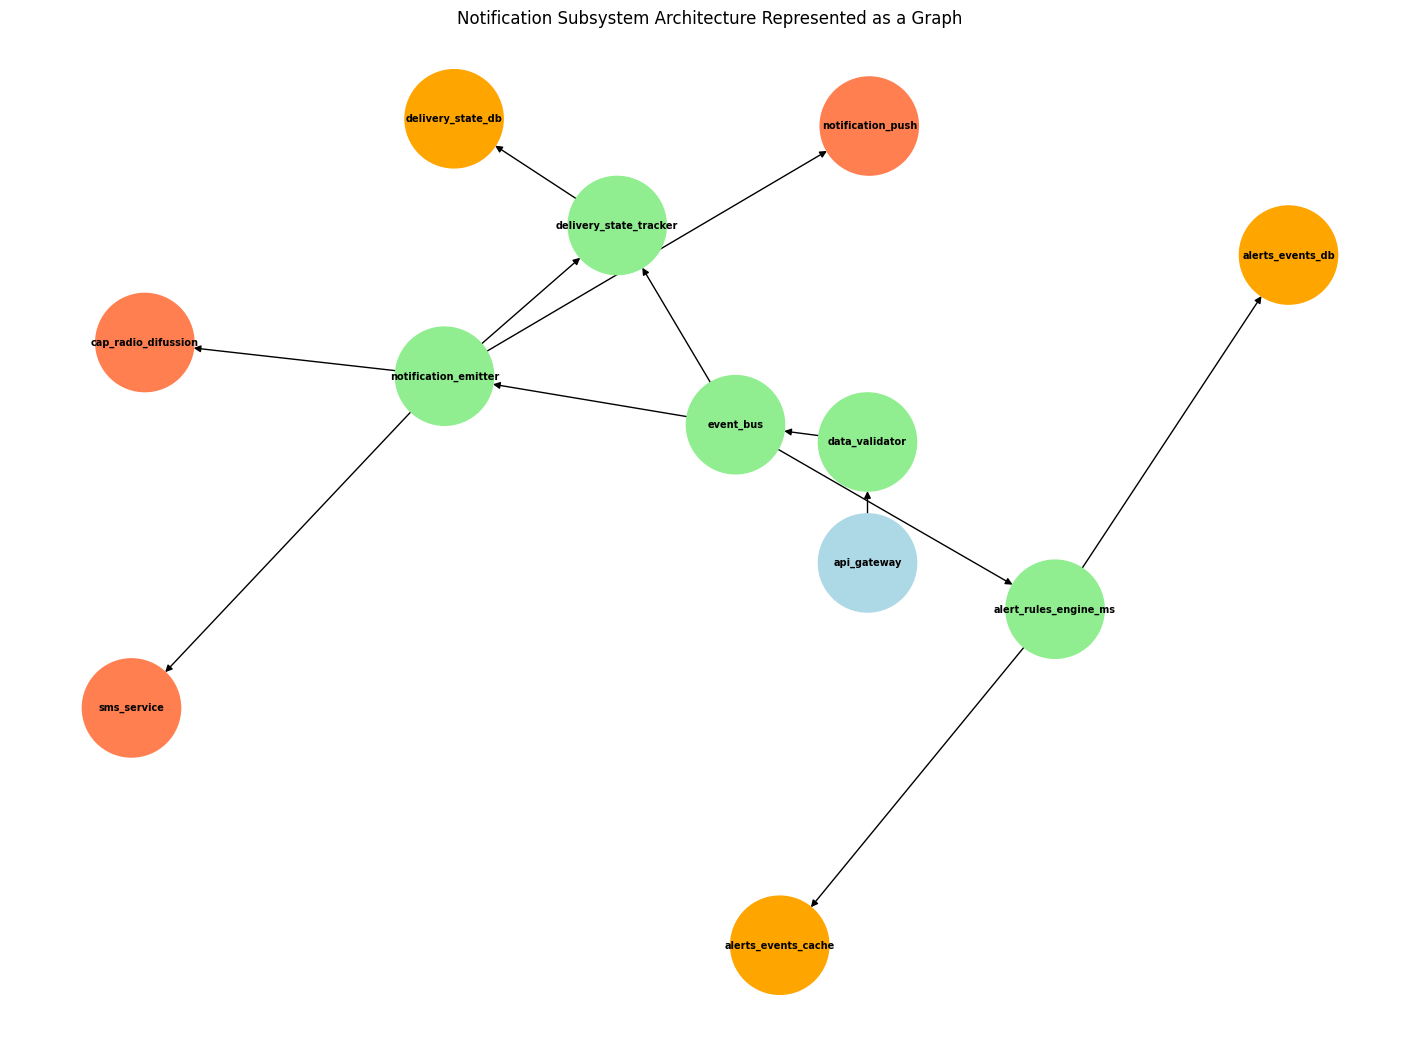


=== Simulating Transactions with Initial Architecture ===

=== Simulation Results ===
Total Transactions: 2000
Successful Transactions: 1447
Failed Transactions: 553

Summary by Transaction Type:
  Alert_trigger: 730 successful, 470 failed
  Status_query: 717 successful, 83 failed

Summary by Component:
  api_gateway: Processed 2000, Failed 553
  data_validator: Processed 1200, Failed 470
  event_bus: Processed 2000, Failed 553
  alert_rules_engine_ms: Processed 1200, Failed 470
  alerts_events_db: Processed 1200, Failed 470
  notification_emitter: Processed 1200, Failed 470
  sms_service: Processed 391, Failed 161
  cap_radio_difussion: Processed 395, Failed 145
  notification_push: Processed 414, Failed 164
  delivery_state_tracker: Processed 800, Failed 83
  delivery_state_db: Processed 800, Failed 83

Details of Failed Transactions:
Source: c4_system via sms_service, Type: alert_trigger, Components: ['api_gateway', 'data_validator', 'event_bus', 'alert_rules_engine_ms', 'alerts_ev

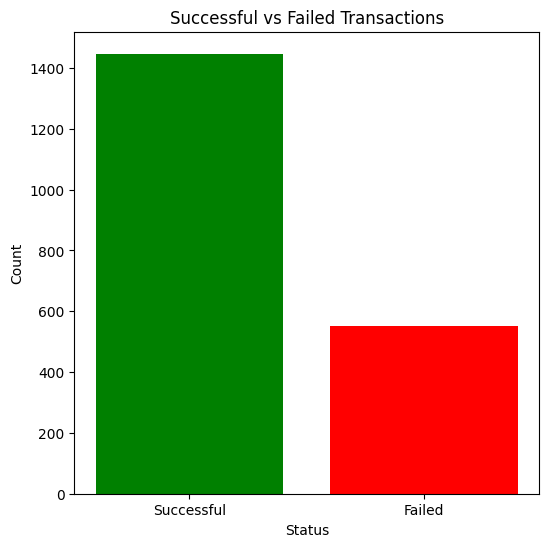

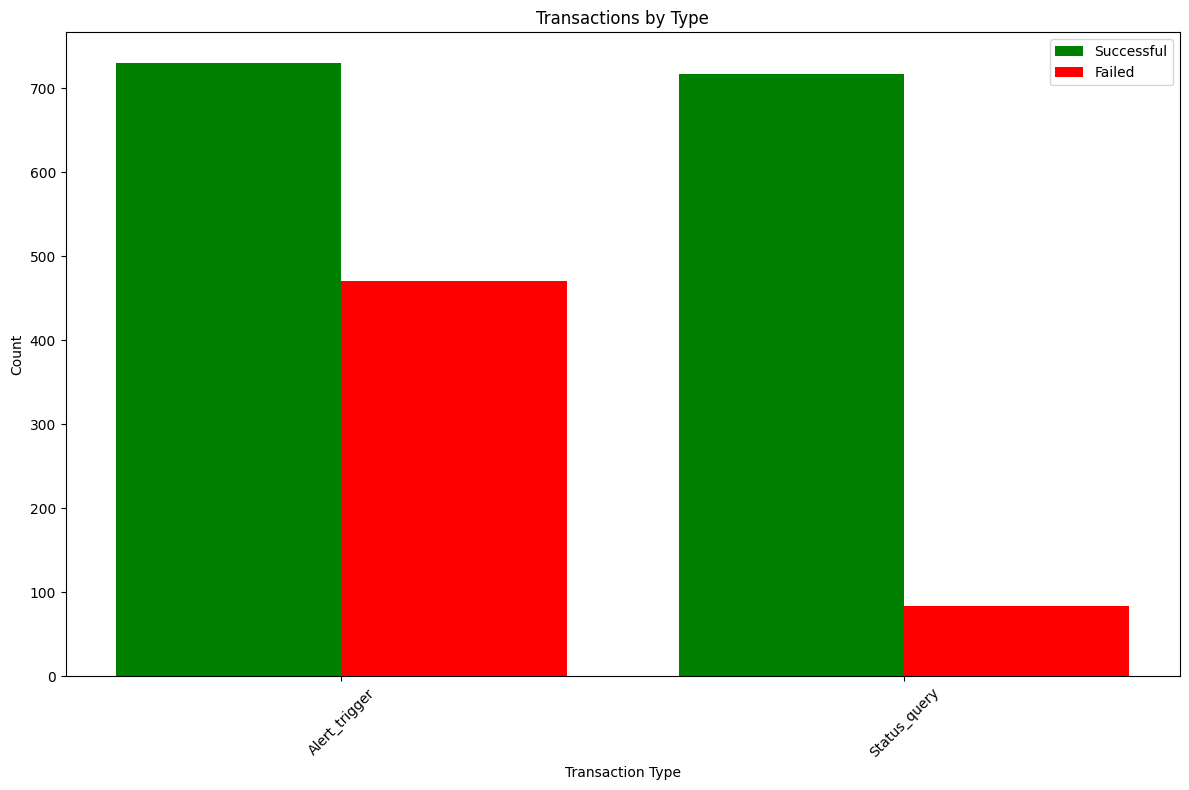


[Failure Scenario] Capacity of 'event_bus' reduced to 50.

=== Simulating Transactions with Failure Scenario ===

=== Simulation Results ===
Total Transactions: 2000
Successful Transactions: 342
Failed Transactions: 1658

Summary by Transaction Type:
  Alert_trigger: 210 successful, 990 failed
  Status_query: 132 successful, 668 failed

Summary by Component:
  api_gateway: Processed 2000, Failed 1658
  data_validator: Processed 1200, Failed 990
  event_bus: Processed 2000, Failed 1658
  alert_rules_engine_ms: Processed 1200, Failed 990
  alerts_events_db: Processed 1200, Failed 990
  notification_emitter: Processed 1200, Failed 990
  sms_service: Processed 390, Failed 329
  cap_radio_difussion: Processed 399, Failed 329
  notification_push: Processed 411, Failed 332
  delivery_state_tracker: Processed 800, Failed 668
  delivery_state_db: Processed 800, Failed 668

Details of Failed Transactions:
Source: c4_system via sms_service, Type: alert_trigger, Components: ['api_gateway', 'data_

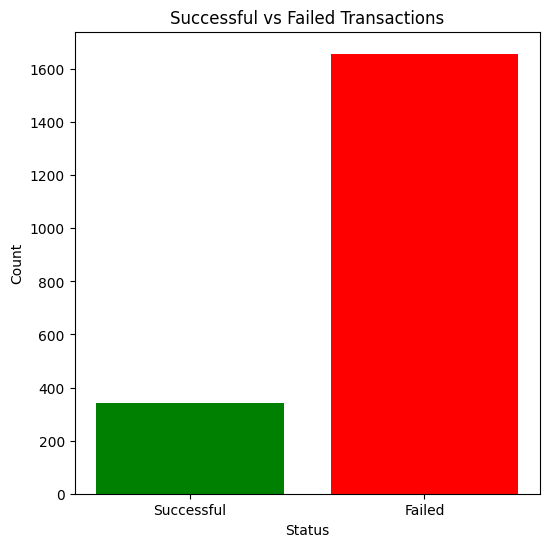

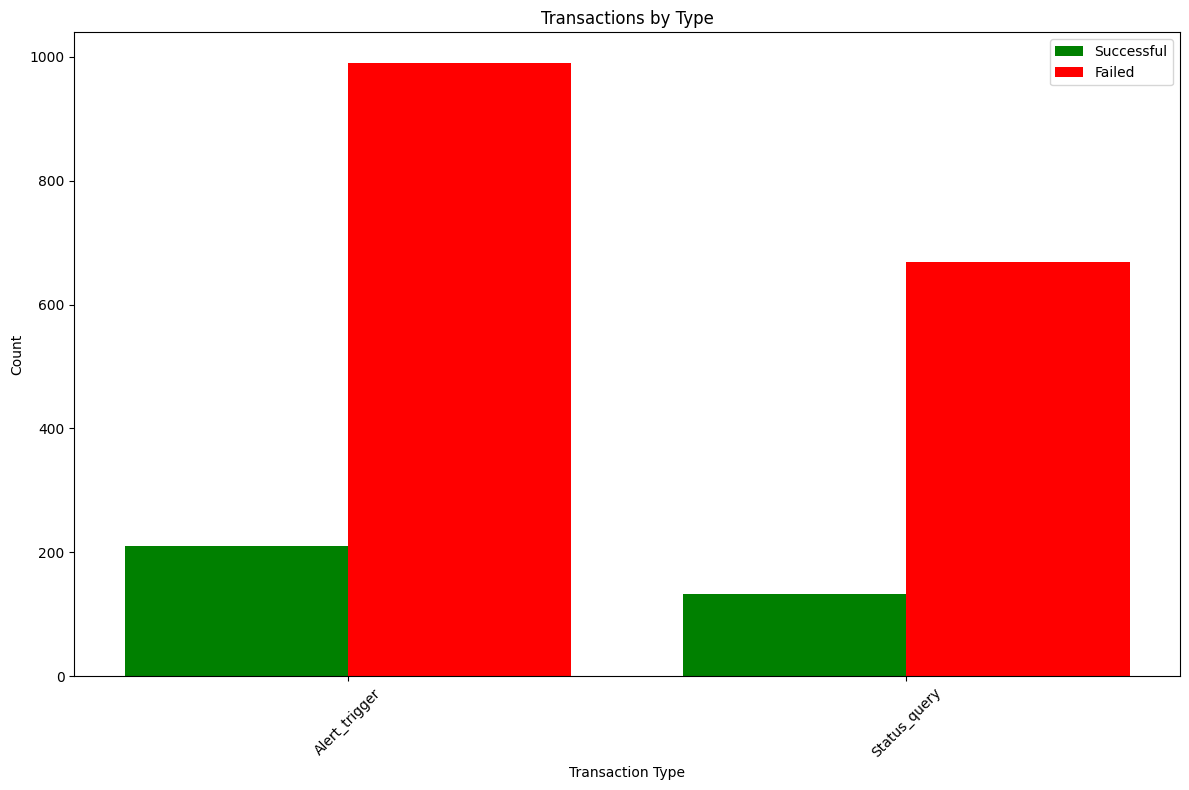


=== Architecture Representation After Failure ===


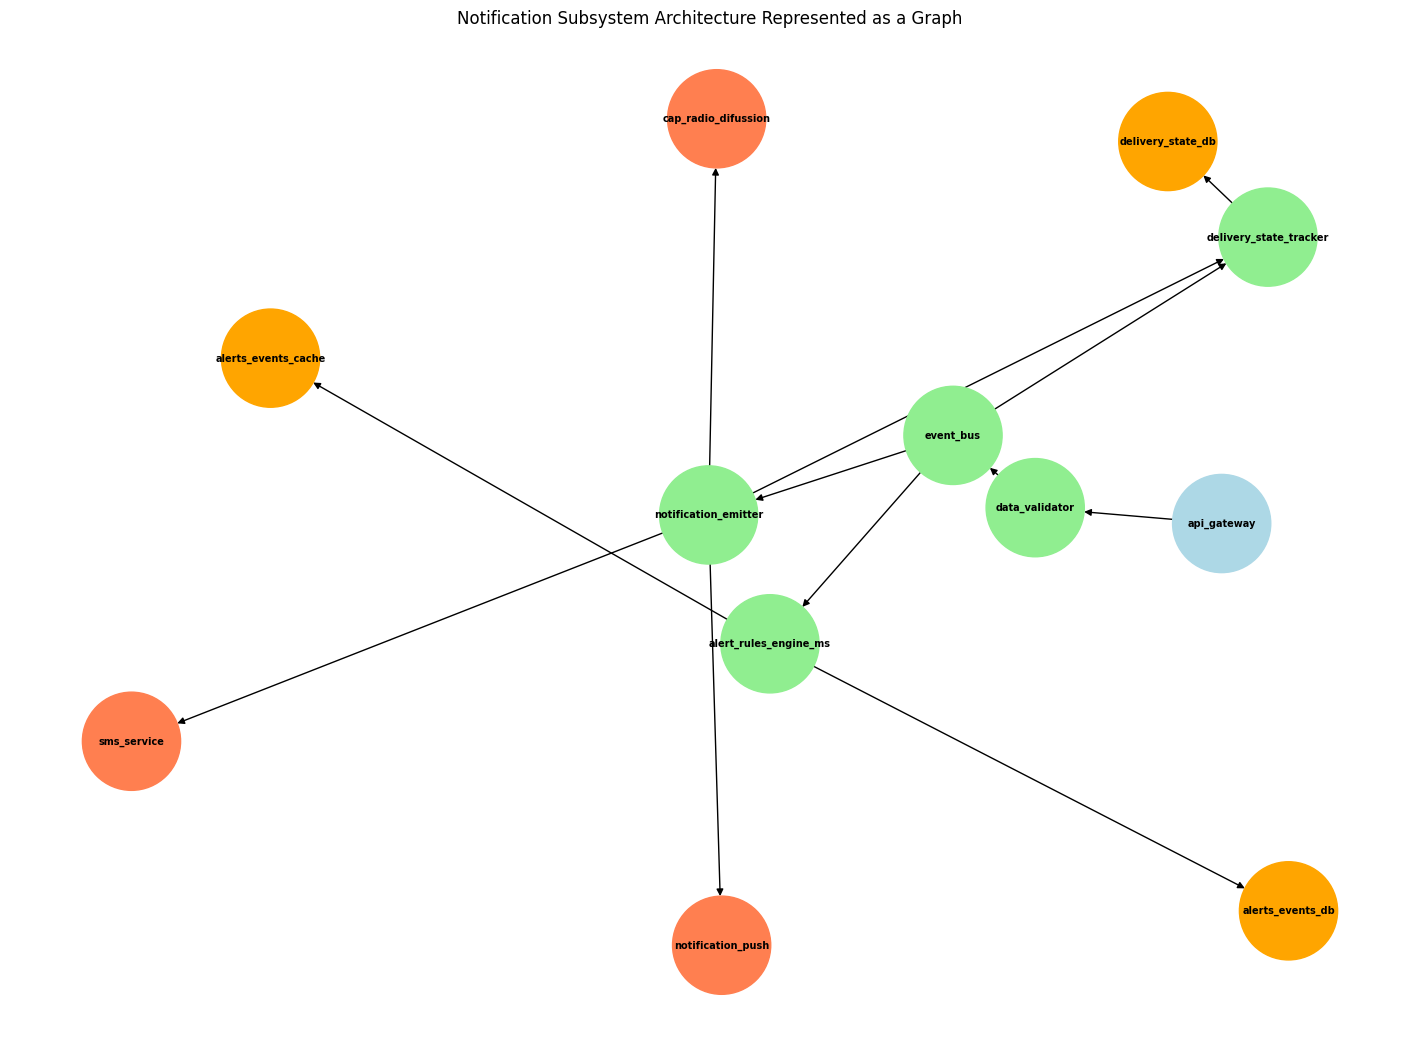

In [8]:
index = 0
current_weight = 1
max_weight = 3
# Para ejecutar la función, simplemente llámala:
run_notification_simulation()